# loss.ipynb

# Import

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn.colors.xkcd_rgb as c

# !!

In [22]:
figpath = ''

# Plot loss

In [3]:
loss_path = '../../data/vae_model/loss_log'

In [19]:
def Plot_loss(season:str, figpath=False):
    # Load loss log
    with open(f'{loss_path}/{season}_vae_loss.txt', 'rb') as f:
        loss_log = pickle.load(f)
        
    # print(f"Max. KL-Div. loss in training: {np.asarray(loss_log['kl_loss']).max()}")

    # Figure
    fig, ax = plt.subplots(figsize=(6, 4))
    
    ## Training
    ax.grid(ls=':', lw=0.5, color='grey')
    ax.plot(loss_log['loss'], color='k', lw=4, label='Total')
    ax.plot(loss_log['reconstruction_loss'], color=c['bluish'], ls=':', lw=4, label='Reconstruction')
    ax.plot(loss_log['kl_loss'], color=c['scarlet'], ls='--', lw=4, label='KL Divergence')

    ax.set_xticks(np.arange(0, 400.1, 100))
    ax.set_xticklabels(np.arange(0, 400.1, 100).astype(int), fontsize=14)
    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_yticks(np.arange(0, 4.1e6, 1e6))
    ax.tick_params(axis='y', labelsize=14)
    ax.yaxis.get_offset_text().set_fontsize(14)
    ax.set_ylabel('Loss', fontsize=14)
    ax.legend(fontsize=14)
    ax.set_title('VAE Training', fontsize=16)
    
    if figpath:
        plt.savefig(f'{figpath}/{season}_vae_loss.png', bbox_inches='tight', facecolor='w', dpi=400)
    plt.show()

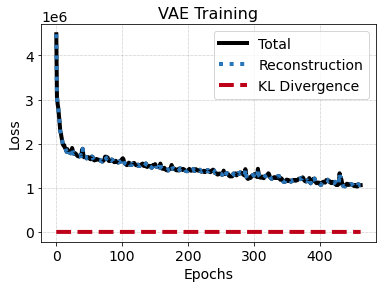

In [21]:
Plot_loss('summer')